In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Blanks

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Replacing blanks with "0"

In [8]:
df["TotalCharges"]=df["TotalCharges"].replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype("float")

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df["customerID"].duplicated().sum()

0

## Converting Senior citizen

In [12]:
def conv(value):
    if value ==1:
        return "yes"
    else:
        return "no"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

        

In [13]:
df["SeniorCitizen"].head()

0    no
1    no
2    no
3    no
4    no
Name: SeniorCitizen, dtype: object

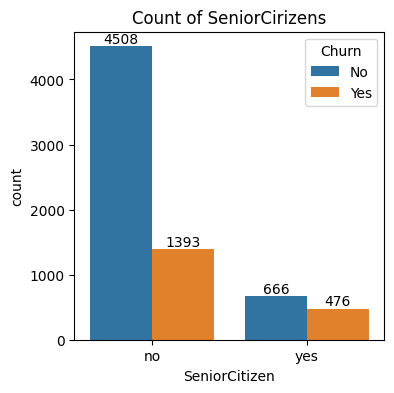

In [43]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x=df['SeniorCitizen'],data=df,hue='Churn')
for i in ax.containers:
    ax.bar_label(i)
plt.title("Count of SeniorCirizens")
plt.show()

Greater number of senior people has been churned out

## Churn rate

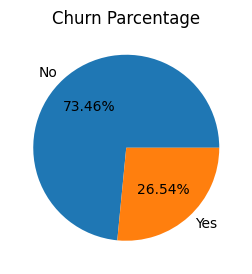

In [16]:
plt.figure(figsize=(3,4))
gb= df.groupby('Churn').size()
plt.pie(gb,labels=gb.index,autopct='%1.2f%%')
plt.title('Churn Parcentage')
plt.show()

From given dataset 26.54 % of customers has been churned out

## Gender

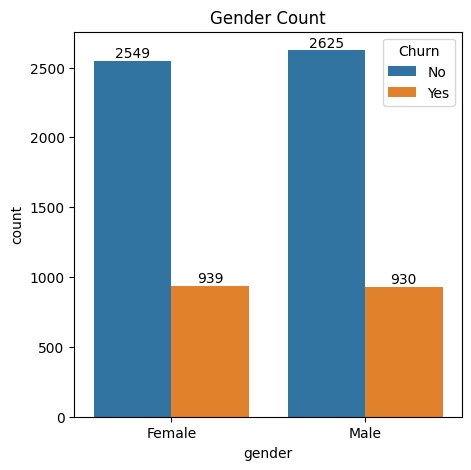

In [37]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x=df['gender'],data=df,hue='Churn')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Gender Count')
plt.show()

Gender-wise Churn and count of Gender

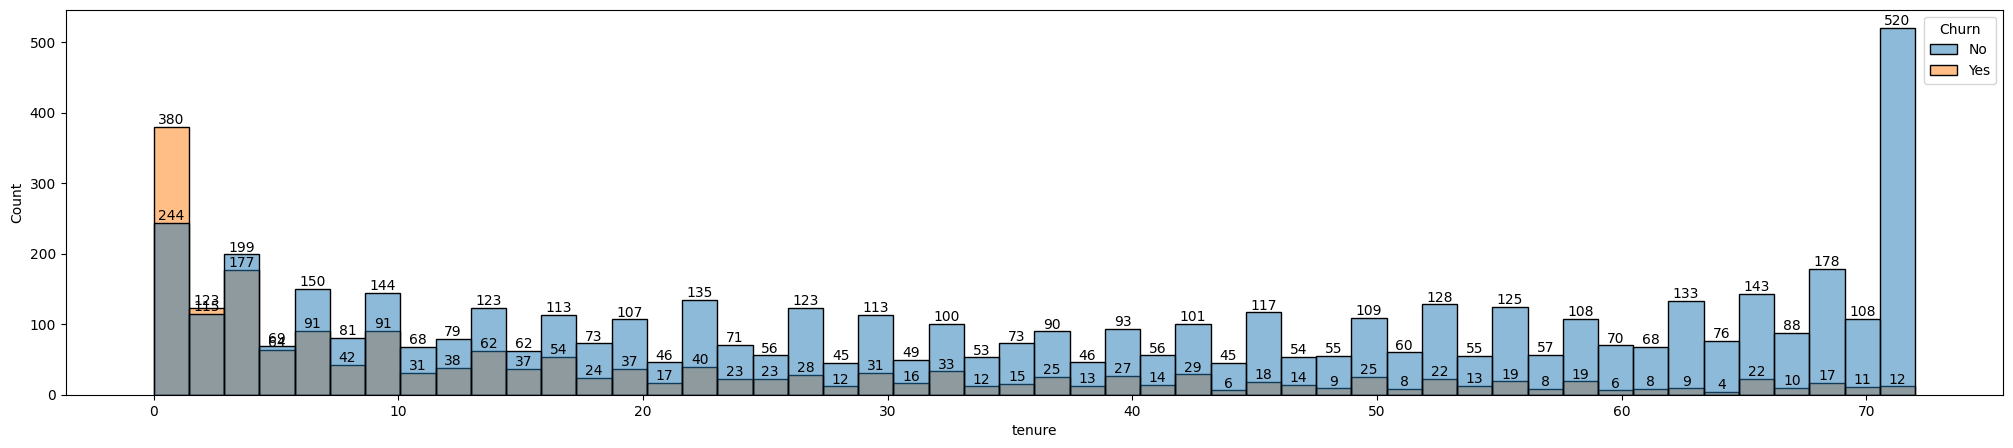

In [92]:
plt.figure(figsize=(25,5))
ax=sns.histplot(x=df['tenure'],data=df,bins=50,hue='Churn')
for i in ax.containers:
    ax.bar_label(i)
plt.show()

People who have used servies for a long time have stayed and who have used our services for 1 to4 month hav churned

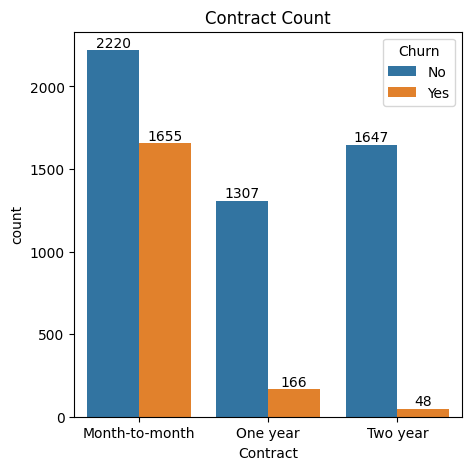

In [99]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x=df['Contract'],data=df,hue='Churn')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Contract Count')
plt.show()

people who have month to month contract are likely to churn then from those who have 1 or 2 years of contract

In [104]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

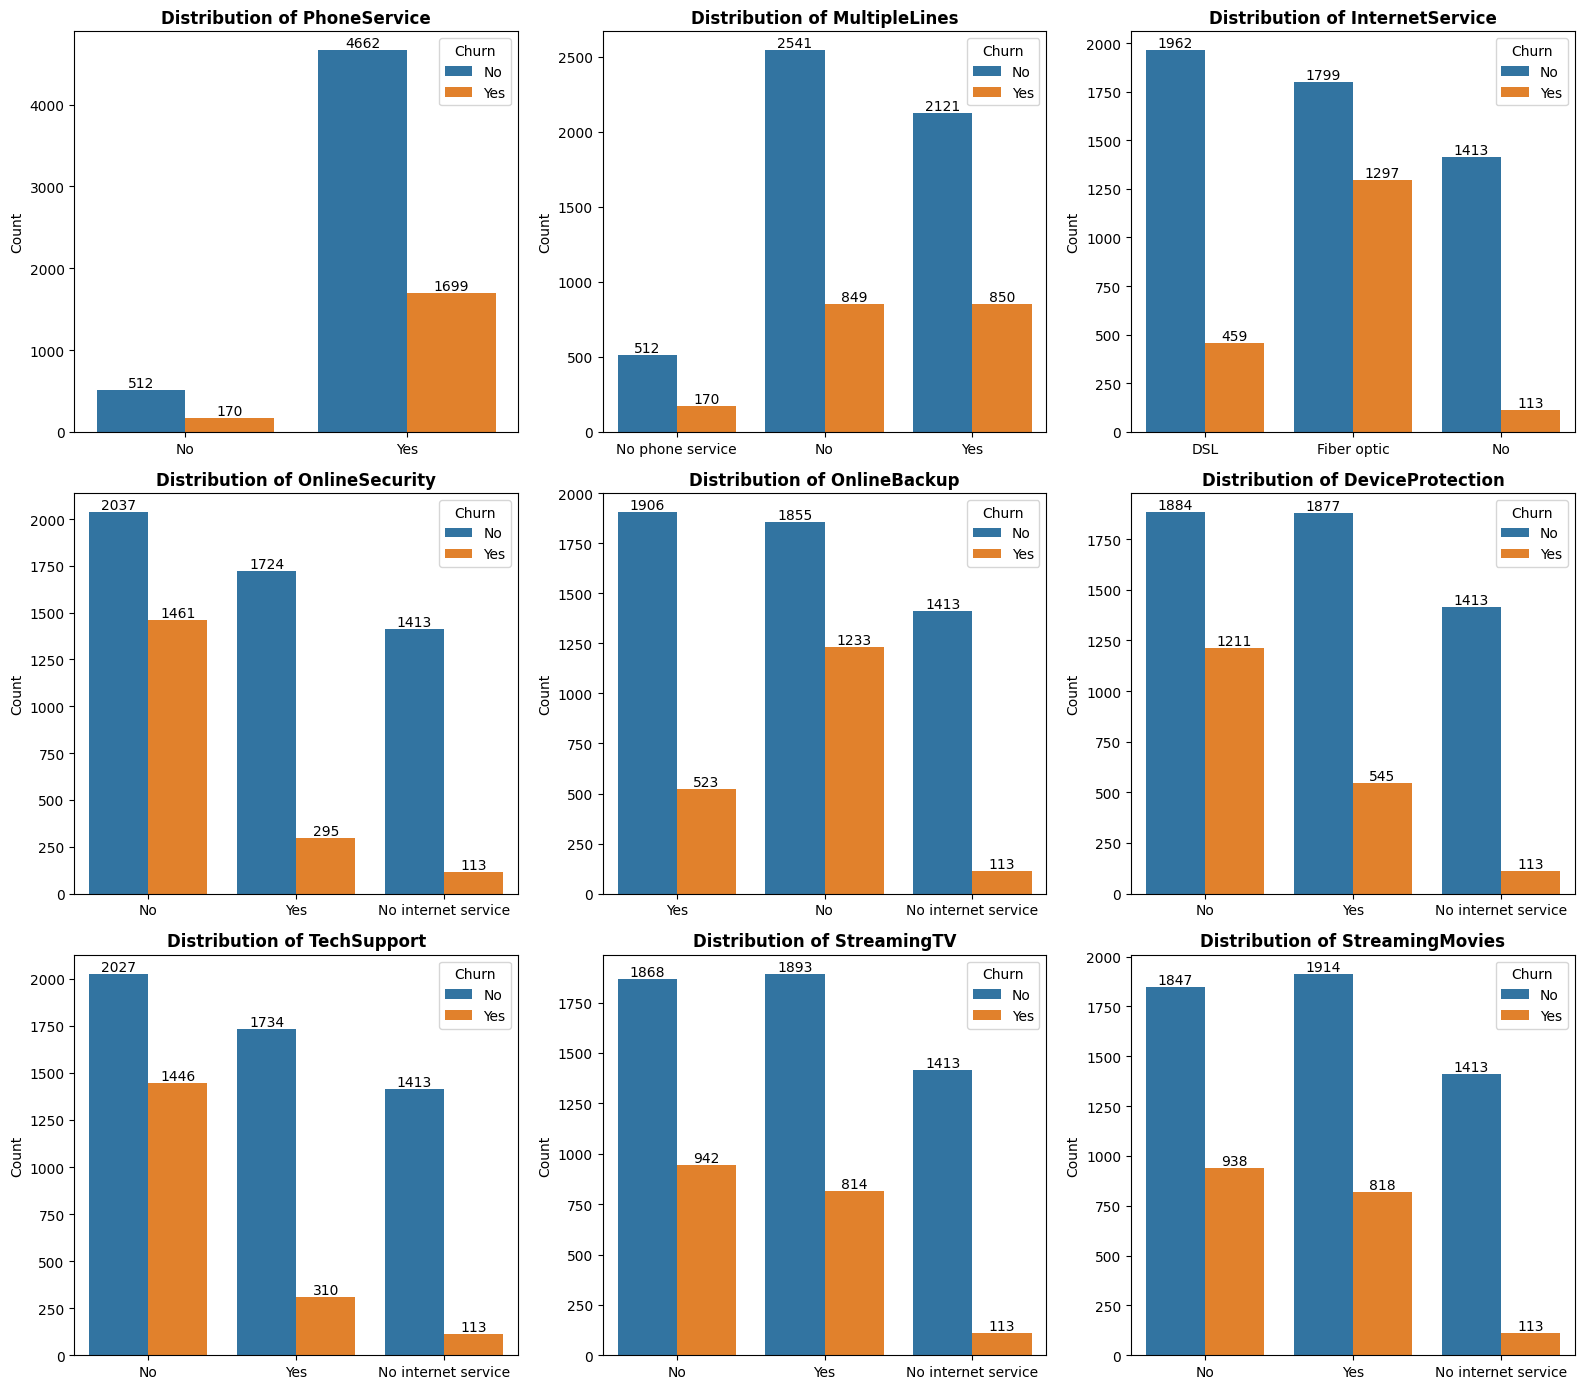

In [106]:
cols = ['PhoneService', 'MultipleLines', 'InternetService', 
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# Set up a 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, col in enumerate(cols):
    # Plot count for each column, colored by Churn
    sns.countplot(x=col, data=df, hue='Churn', ax=axes[i])
    
    # Add title and formatting
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    
    # Optional: Add bar labels for clarity
    for container in axes[i].containers:
        axes[i].bar_label(container)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

# The "Protective Service" Shield
Finding: Customers who DO NOT have OnlineSecurity, TechSupport, or OnlineBackup show the highest churn rates in the entire dataset.

Insight: These services act as the strongest "anchors." When a customer feels their data is secure and help is available, they are much less likely to leave.

# The Fiber Optic Risk
Finding: Fiber Optic users have a massive churn count (1,297) compared to DSL users (459).

Insight: Even though Fiber is a premium service, it is your highest-risk category. This could be due to higher pricing or higher expectations for stability that aren't being met.

# Internet vs. Basic Phone Loyalty
Finding: Across all nine charts, the "No internet service" category has the lowest churn.

Insight: Customers who only use basic Phone Services are extremely loyal and stable. The churn problem is almost entirely concentrated within the internet-subscriber base.

# Utility Over Entertainment
Finding: StreamingTV and StreamingMovies do not significantly reduce churn. The orange bars (Churn: Yes) remain high even for subscribers of these services.

Insight: Customers value "Safety and Support" (Online Security/Tech Support) much more than "Entertainment" when deciding whether to stay with the provider.

# Strategic Recommendation
Focus on "Stickiness": To reduce churn, the company should bundle Tech Support and Online Security with every Fiber Optic plan. High-speed internet is the product, but security and support are what make the customer stay.

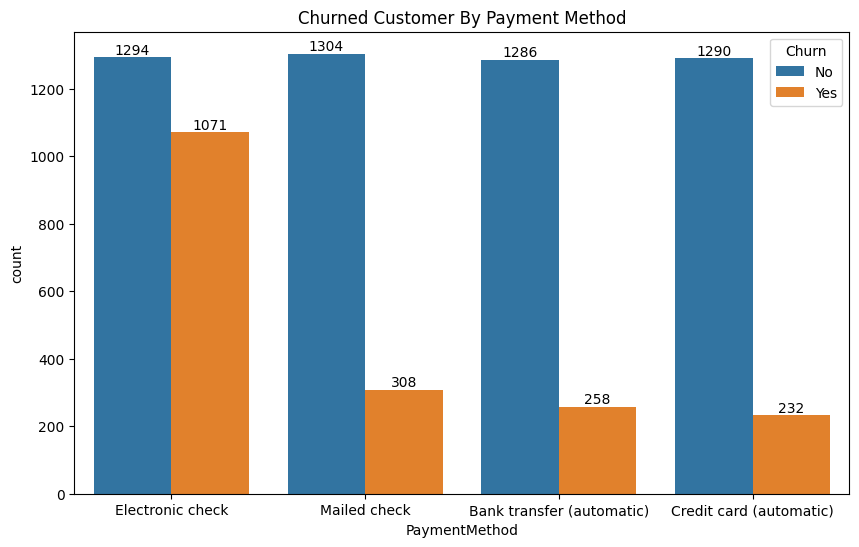

In [130]:
plt.figure(figsize=(10,6))
ax=sns.countplot(x=df['PaymentMethod'],data=df,hue='Churn')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Churned Customer By Payment Method')
plt.show()

## 1. The "Support" Safety Net
Customers who do not have Tech Support, Online Security, or Online Backup are significantly more likely to churn. These services act as "anchors" that keep customers loyal.

## 2. The Payment Method Trap
Electronic Check is a major red flag. It has the highest churn volume of any payment category. In contrast, customers on Automatic Payments (Credit Card or Bank Transfer) are the most loyal.
